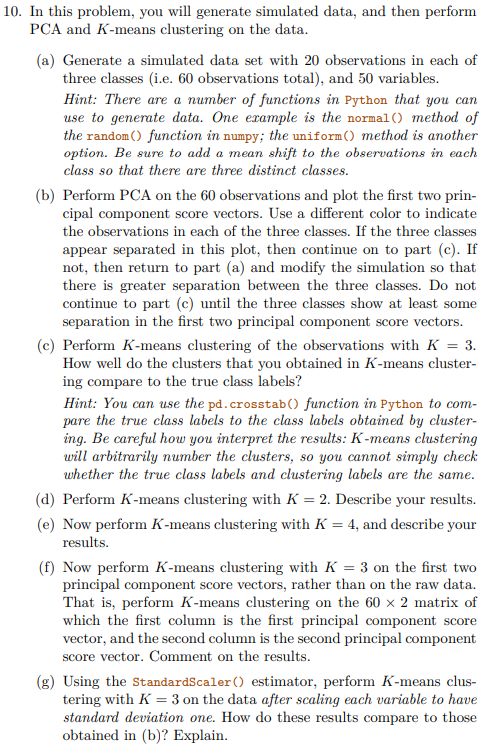

In [1]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Part (a): Generate simulated data with 3 classes
def generate_simulated_data():
    """
    Generate simulated data with 20 observations in each of 3 classes (60 total)
    and 50 variables with distinct mean shifts for each class
    """
    n_obs_per_class = 20
    n_variables = 50
    n_classes = 3

    # Initialize empty arrays
    X = np.zeros((n_obs_per_class * n_classes, n_variables))
    y = np.zeros(n_obs_per_class * n_classes)

    # Generate data for each class with different mean shifts
    for class_idx in range(n_classes):
        start_idx = class_idx * n_obs_per_class
        end_idx = (class_idx + 1) * n_obs_per_class

        # Add mean shift to create separation between classes
        mean_shift = (class_idx + 1) * 2  # Different mean for each class

        # Generate data from normal distribution with mean shift
        X[start_idx:end_idx, :] = np.random.normal(
            loc=mean_shift,
            scale=1.0,  # Standard deviation of 1
            size=(n_obs_per_class, n_variables)
        )

        y[start_idx:end_idx] = class_idx

    return X, y

# Generate the data
X, y_true = generate_simulated_data()
print(f"Data shape: {X.shape}")
print(f"True class labels: {np.unique(y_true, return_counts=True)}")

Data shape: (60, 50)
True class labels: (array([0., 1., 2.]), array([20, 20, 20]))


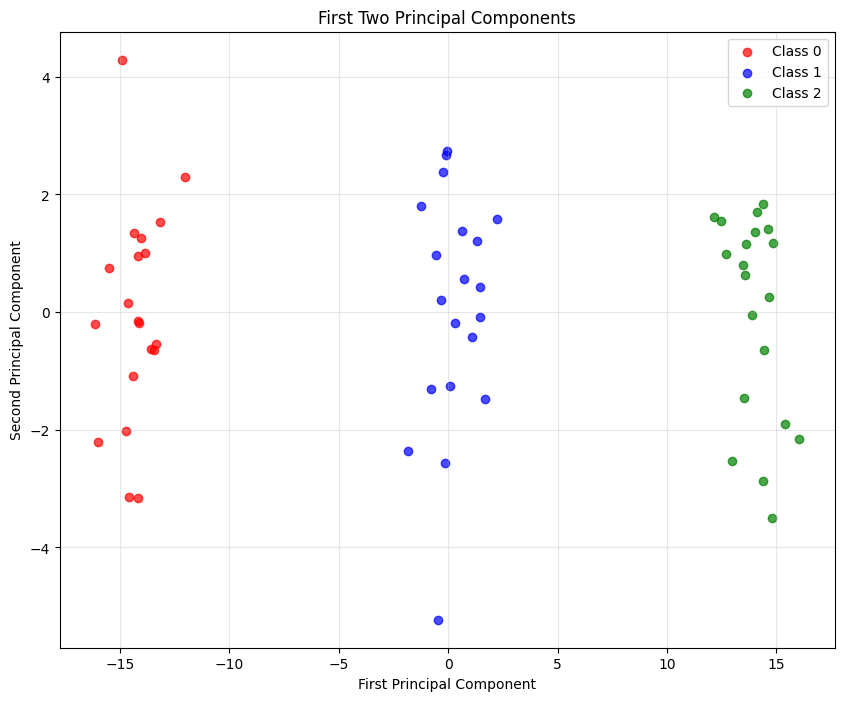

Explained variance ratio - PC1: 0.745, PC2: 0.018


In [3]:
# Part (b): Perform PCA and plot
def perform_pca_and_plot(X, y_true):
    # Perform PCA
    pca = PCA()
    X_pca = pca.fit_transform(X)

    # Create a DataFrame for easier plotting
    pca_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'Class': y_true.astype(int)
    })

    # Plot the first two principal components
    plt.figure(figsize=(10, 8))
    colors = ['red', 'blue', 'green']
    for class_idx in range(3):
        class_data = pca_df[pca_df['Class'] == class_idx]
        plt.scatter(class_data['PC1'], class_data['PC2'],
                   c=colors[class_idx], label=f'Class {class_idx}', alpha=0.7)

    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title('First Two Principal Components')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print explained variance
    print(f"Explained variance ratio - PC1: {pca.explained_variance_ratio_[0]:.3f}, "
          f"PC2: {pca.explained_variance_ratio_[1]:.3f}")

    return X_pca, pca

# Perform PCA and plot
X_pca, pca = perform_pca_and_plot(X, y_true)

In [4]:
# Part (c): K-means clustering with K=3
def kmeans_evaluation(X, y_true, k=3, title="K-means Clustering"):
    # Perform K-means clustering
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_pred = kmeans.fit_predict(X)

    # Create cross-tabulation
    cross_tab = pd.crosstab(
        pd.Series(y_true, name='True Class'),
        pd.Series(y_pred, name='Predicted Cluster')
    )

    print(f"\n{title} (K={k})")
    print("Cross-tabulation:")
    print(cross_tab)

    # Calculate accuracy (need to account for arbitrary cluster labeling)
    from scipy.optimize import linear_sum_assignment

    # Create cost matrix for optimal assignment
    cost_matrix = -cross_tab.values  # Negative because we want to maximize matches
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    accuracy = cross_tab.values[row_ind, col_ind].sum() / len(y_true)
    print(f"Adjusted accuracy: {accuracy:.3f}")

    return y_pred, accuracy

# Perform K-means with K=3 on original data
y_pred_k3, acc_k3 = kmeans_evaluation(X, y_true, k=3, title="K-means on Original Data (K=3)")


K-means on Original Data (K=3) (K=3)
Cross-tabulation:
Predicted Cluster   0   1   2
True Class                   
0.0                 0   0  20
1.0                20   0   0
2.0                 0  20   0
Adjusted accuracy: 1.000



K-means on Original Data (K=2) (K=2)
Cross-tabulation:
Predicted Cluster   0   1
True Class               
0.0                 0  20
1.0                20   0
2.0                20   0
Adjusted accuracy: 0.667


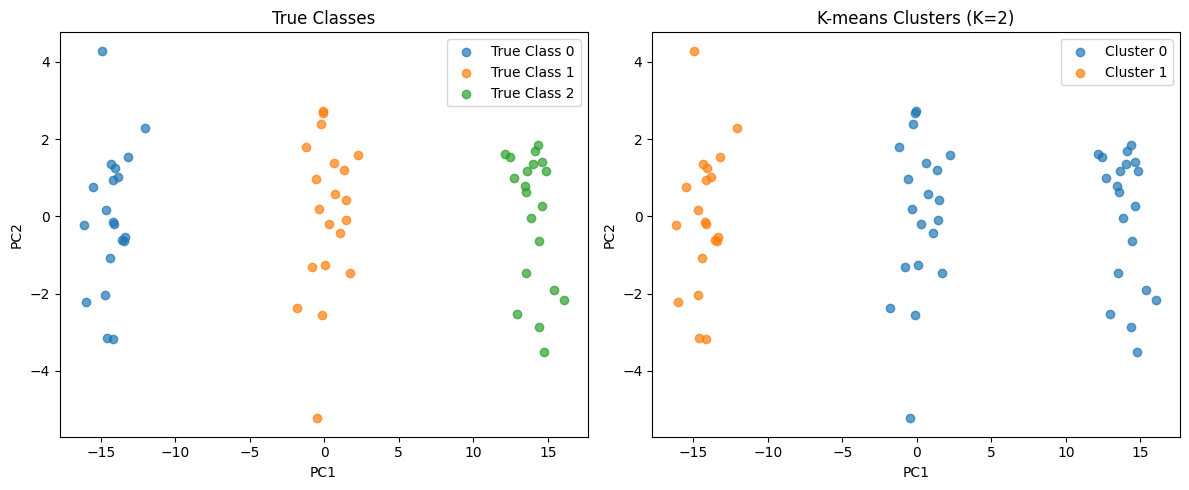

In [5]:
# Part (d): K-means clustering with K=2
y_pred_k2, acc_k2 = kmeans_evaluation(X, y_true, k=2, title="K-means on Original Data (K=2)")

# Visualize the K=2 results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for class_idx in range(3):
    class_mask = (y_true == class_idx)
    plt.scatter(X_pca[class_mask, 0], X_pca[class_mask, 1],
               label=f'True Class {class_idx}', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('True Classes')
plt.legend()

plt.subplot(1, 2, 2)
for cluster_idx in range(2):
    cluster_mask = (y_pred_k2 == cluster_idx)
    plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
               label=f'Cluster {cluster_idx}', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clusters (K=2)')
plt.legend()

plt.tight_layout()
plt.show()


K-means on Original Data (K=4) (K=4)
Cross-tabulation:
Predicted Cluster   0   1  2   3
True Class                      
0.0                 0  20  0   0
1.0                 0   0  8  12
2.0                20   0  0   0
Adjusted accuracy: 0.867


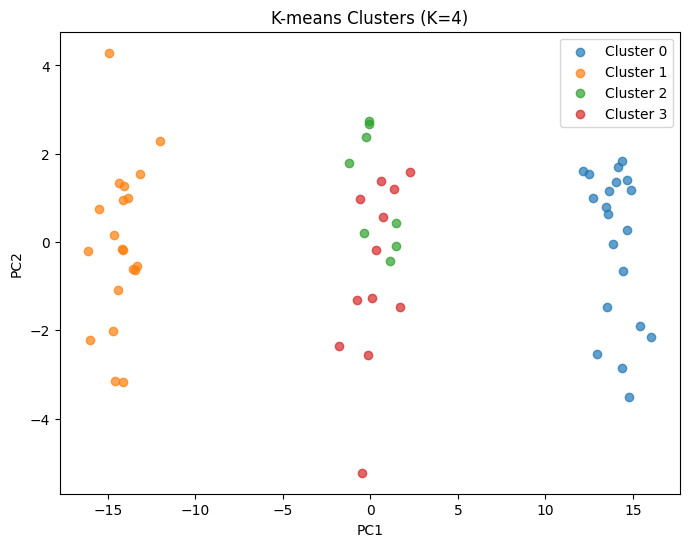

In [6]:
# Part (e): K-means clustering with K=4
y_pred_k4, acc_k4 = kmeans_evaluation(X, y_true, k=4, title="K-means on Original Data (K=4)")

# Visualize the K=4 results
plt.figure(figsize=(8, 6))
for cluster_idx in range(4):
    cluster_mask = (y_pred_k4 == cluster_idx)
    plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
               label=f'Cluster {cluster_idx}', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clusters (K=4)')
plt.legend()
plt.show()


K-means on First Two Principal Components (K=3) (K=3)
Cross-tabulation:
Predicted Cluster   0   1   2
True Class                   
0.0                 0  20   0
1.0                20   0   0
2.0                 0   0  20
Adjusted accuracy: 1.000


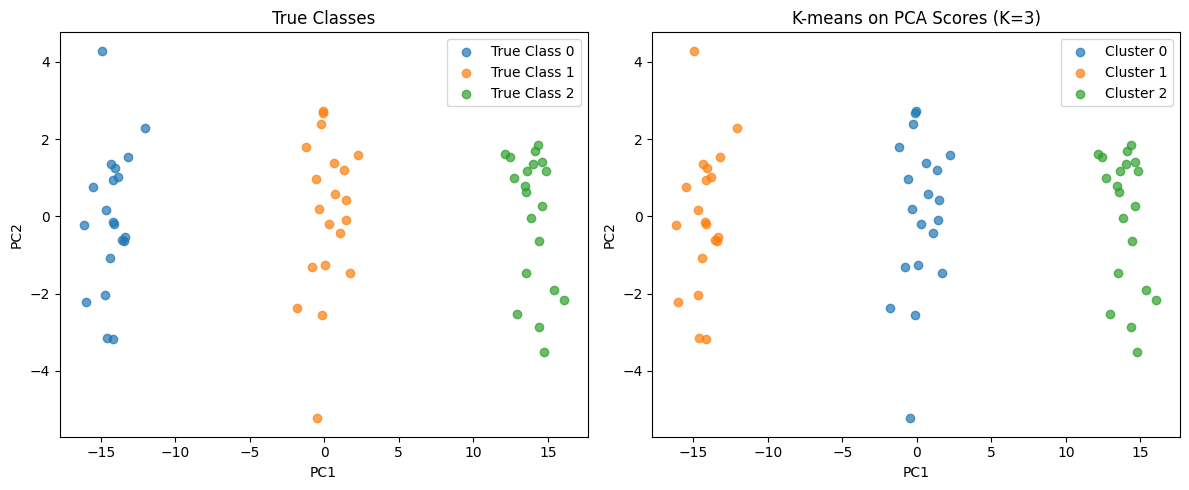

In [7]:
# Part (f): K-means on first two principal components
X_pca_2d = X_pca[:, :2]  # Use only first two principal components

y_pred_pca, acc_pca = kmeans_evaluation(
    X_pca_2d, y_true, k=3,
    title="K-means on First Two Principal Components (K=3)"
)

# Visualize clustering on PCA space
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for class_idx in range(3):
    class_mask = (y_true == class_idx)
    plt.scatter(X_pca[class_mask, 0], X_pca[class_mask, 1],
               label=f'True Class {class_idx}', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('True Classes')
plt.legend()

plt.subplot(1, 2, 2)
for cluster_idx in range(3):
    cluster_mask = (y_pred_pca == cluster_idx)
    plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
               label=f'Cluster {cluster_idx}', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means on PCA Scores (K=3)')
plt.legend()

plt.tight_layout()
plt.show()


K-means on Scaled Data (K=3)
Cross-tabulation:
Predicted Cluster   0   1   2
True Class                   
0.0                 0   0  20
1.0                20   0   0
2.0                 0  20   0
Adjusted accuracy: 1.000


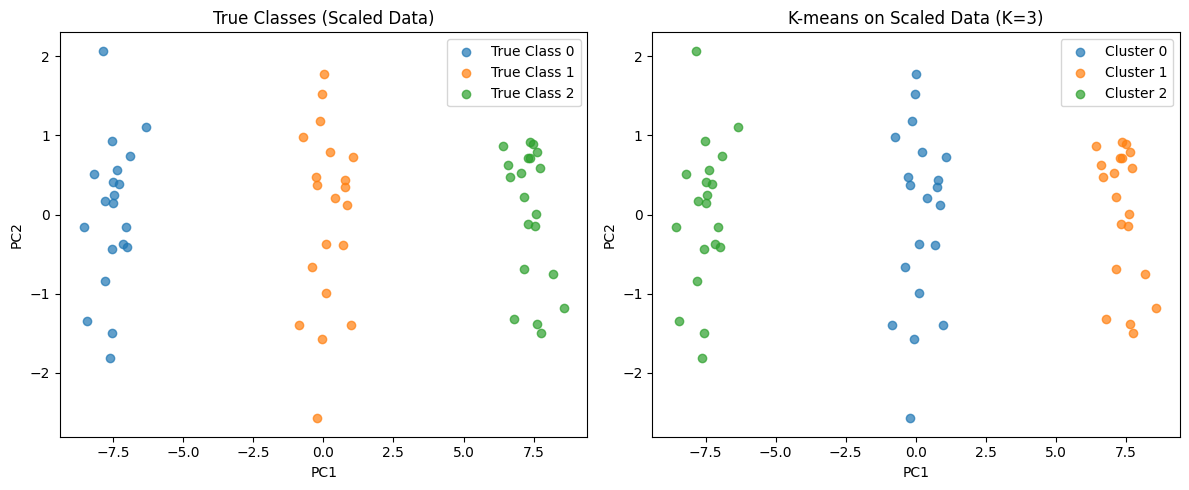


Explained variance ratio (scaled data) - PC1: 0.744, PC2: 0.018


In [8]:
# Part (g): K-means on scaled data
def kmeans_on_scaled_data(X, y_true, k=3):
    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform K-means on scaled data
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_pred_scaled = kmeans.fit_predict(X_scaled)

    # Create cross-tabulation
    cross_tab = pd.crosstab(
        pd.Series(y_true, name='True Class'),
        pd.Series(y_pred_scaled, name='Predicted Cluster')
    )

    print("\nK-means on Scaled Data (K=3)")
    print("Cross-tabulation:")
    print(cross_tab)

    # Calculate adjusted accuracy
    from scipy.optimize import linear_sum_assignment
    cost_matrix = -cross_tab.values
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    accuracy = cross_tab.values[row_ind, col_ind].sum() / len(y_true)
    print(f"Adjusted accuracy: {accuracy:.3f}")

    # Perform PCA on scaled data for visualization
    pca_scaled = PCA()
    X_pca_scaled = pca_scaled.fit_transform(X_scaled)

    # Plot results
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    for class_idx in range(3):
        class_mask = (y_true == class_idx)
        plt.scatter(X_pca_scaled[class_mask, 0], X_pca_scaled[class_mask, 1],
                   label=f'True Class {class_idx}', alpha=0.7)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('True Classes (Scaled Data)')
    plt.legend()

    plt.subplot(1, 2, 2)
    for cluster_idx in range(3):
        cluster_mask = (y_pred_scaled == cluster_idx)
        plt.scatter(X_pca_scaled[cluster_mask, 0], X_pca_scaled[cluster_mask, 1],
                   label=f'Cluster {cluster_idx}', alpha=0.7)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('K-means on Scaled Data (K=3)')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"\nExplained variance ratio (scaled data) - PC1: {pca_scaled.explained_variance_ratio_[0]:.3f}, "
          f"PC2: {pca_scaled.explained_variance_ratio_[1]:.3f}")

    return y_pred_scaled, accuracy, X_pca_scaled

# Perform K-means on scaled data
y_pred_scaled, acc_scaled, X_pca_scaled = kmeans_on_scaled_data(X, y_true)